先用Random Forest做一遍——计算其特征的man的预测率

In [1065]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from matplotlib.pyplot import figure
from statsmodels.tsa.vector_ar.var_model import test_normality
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeRegressor

from scipy.stats import trim_mean
from scipy.stats import median_abs_deviation
from scipy.stats import spearmanr

导入数据：

In [1066]:
train = pd.read_csv("../titanic/train.csv")
test = pd.read_csv("../titanic/test.csv")
y_test = pd.read_csv("../titanic/truth.csv")

test['Survived'] = np.nan

data = pd.concat([train, test], ignore_index=True, sort=False)

具有缺失值的特征有：Age, Fare, Cabin, Embarked

先填充Cabin和Embarked，再用DecisionTreeRegressor填充Age和Fare

In [1067]:
# 填充Embarked
data['Embarked'] = data['Embarked'].fillna('S')

In [1068]:
# 填充Cabin
data['Deck'] = data['Cabin'].apply(lambda x: 'M' if pd.isna(x) else x[0])
data.loc[data[data['Deck']=='T'].index, 'Deck'] = 'A'
data.replace({'Deck':['A','B','C']},'ABC', inplace=True)
data.replace({'Deck':['D','E']}, 'DE', inplace=True)
data.replace({'Deck':['F','G']},'FG', inplace=True)

In [1069]:
data.drop(columns='Cabin', axis=1, inplace=True)

构建Title字段

In [1070]:
data['Title'] = 'man'
data.loc[data['Name'].str.contains('Master', na=False),'Title'] = 'boy'
data.loc[data['Sex']=='female','Title'] = 'woman'

In [1071]:
null_index = data[data['Age'].isnull()].index

In [1072]:
null_fare = data[data['Fare'].isnull()].index

In [1073]:
data['Title_Encode'] = data['Title'].map({'man':0,'woman':1,'boy':2})
data['Embarked_code'] = data['Embarked'].map({'S':0,'Q':1,'C':2})
data['Sex_code'] = data['Sex'].map({'male':0, 'female':1})

In [1074]:
def impute_with_tree(df, target, features):
    df = df.copy()

    # 用中位数进行填充
    for f in features:
        if df[f].isnull().any():
            df[f] = df[f].fillna(df[f].median())
    x_train = df[df[target].notnull()][features]
    x_test = df[df[target].isnull()][features]
    if len(x_test) == 0:
        return df[target]
    y_train = df[df[target].notnull()][target]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(x_train, y_train)
    df.loc[df[target].isnull(), target]  = model.predict(x_test)
    return df[target]

data['Age'] = impute_with_tree(data, 'Age', ['Title_Encode', 'Parch','SibSp','Pclass'])

# 填 Fare：用 Title_code, Pclass, Embarked_code, Sex_code, Age
data['Fare'] = impute_with_tree(data, 'Fare', ['Title_Encode','Pclass','Embarked_code','Sex_code','Age'])

In [1075]:
data['FamilySize'] = data['Parch'] + data['SibSp'] + 1
data['Ticket'] = data['Ticket'].astype(str).str.strip()

In [1076]:
data['TicketFreq'] = data.groupby('Ticket')['Ticket'].transform('count')

In [1077]:
data['Surname'] = data['Name'].str.split(',').str[0].str.strip()

In [1078]:
train_ft = data[data['PassengerId']<=891][['PassengerId','Surname','Ticket','Survived']]
test_df = data[data['PassengerId']>891][['PassengerId','Surname','Ticket']]

family_survived = train_ft.groupby('Surname').agg(
    survival_rate = ('Survived', 'mean'),
    members = ('Survived','size')
)

family_rate = family_survived.loc[family_survived['members']>1,'survival_rate'].to_dict()

ticket_survived = train_ft.groupby('Ticket').agg(
    survival_rate = ('Survived','mean'),
    members = ('Survived', 'size')
)

ticket_rate = ticket_survived.loc[ticket_survived['members']>1,'survival_rate'].to_dict()

In [1079]:
mean_survival_rate = np.mean(train['Survived'])
# Family
train_ft['FamilySurvivalRate'] = train_ft['Surname'].map(family_rate).fillna(mean_survival_rate)
train_ft['FamilySurvivalRate_NA'] = train_ft['Surname'].map(family_rate).notna().astype(int)

test_df['FamilySurvivalRate'] = test_df['Surname'].map(family_rate).fillna(mean_survival_rate)
test_df['FamilySurvivalRate_NA'] = test_df['Surname'].map(family_rate).notna().astype(int)

# Ticket
train_ft['TicketSurvivalRate'] = train_ft['Ticket'].map(ticket_rate).fillna(mean_survival_rate)
train_ft['TicketSurvivalRate_NA'] = train_ft['Ticket'].map(ticket_rate).notna().astype(int)

test_df['TicketSurvivalRate'] = test_df['Ticket'].map(ticket_rate).fillna(mean_survival_rate)
test_df['TicketSurvivalRate_NA'] = test_df['Ticket'].map(ticket_rate).notna().astype(int)

In [1080]:
for df in [train_ft, test_df]:
    df['Survival_Rate'] = (df['FamilySurvivalRate']+df['TicketSurvivalRate'])/2
    df['Survival_Rate_NA'] = (df['FamilySurvivalRate_NA'] + df['TicketSurvivalRate_NA'])/2

In [1081]:
ft_total = pd.concat([train_ft.drop('Survived', axis=1), test_df])
data = pd.merge(data, ft_total, on=['PassengerId','Surname','Ticket'])

In [1082]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Sex_code,FamilySize,TicketFreq,Surname,FamilySurvivalRate,FamilySurvivalRate_NA,TicketSurvivalRate,TicketSurvivalRate_NA,Survival_Rate,Survival_Rate_NA
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,2,1,Braund,0.000000,1,0.383838,0,0.191919,0.5
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,...,1,2,2,Cumings,0.383838,0,0.383838,0,0.383838,0.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,1,1,Heikkinen,0.383838,0,0.383838,0,0.383838,0.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,1,2,2,Futrelle,0.500000,1,0.500000,1,0.500000,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,1,1,Allen,0.500000,1,0.383838,0,0.441919,0.5


In [1083]:
data['FareAdj'] = data['Fare']/data['TicketFreq']

类别变量编码

In [1084]:
data['Age'] = pd.qcut(data['Age'], q=10)

In [1085]:
# features = ['Age','Fare','Sex']

features = ['Age','Sex']

for i in features:
    data[i] = LabelEncoder().fit_transform(data[i])

In [1086]:
features = ['Embarked','Deck','Pclass']

data = pd.get_dummies(data, columns=features, dtype='int', drop_first=True)
data.head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title,...,Survival_Rate,Survival_Rate_NA,FareAdj,Embarked_Q,Embarked_S,Deck_DE,Deck_FG,Deck_M,Pclass_2,Pclass_3
0,1,0.0,"Braund, Mr. Owen Harris",1,2,1,0,A/5 21171,7.2500,man,...,0.191919,0.5,7.25000,0,1,0,0,1,0,1
1,2,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",0,7,1,0,PC 17599,71.2833,woman,...,0.383838,0.0,35.64165,0,0,0,0,0,0,0
2,3,1.0,"Heikkinen, Miss. Laina",0,3,0,0,STON/O2. 3101282,7.9250,woman,...,0.383838,0.0,7.92500,0,1,0,0,1,0,1
3,4,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,7,1,0,113803,53.1000,woman,...,0.500000,1.0,26.55000,0,1,0,0,0,0,0
4,5,0.0,"Allen, Mr. William Henry",1,7,0,0,373450,8.0500,man,...,0.441919,0.5,8.05000,0,1,0,0,1,0,1


In [1087]:
drop_cols = ['PassengerId','Name','SibSp','Parch','Ticket','TicketSurvivalRate','FamilySurvivalRate','TicketSurvivalRate_NA','FamilySurvivalRate_NA','Surname','Title_Encode','Embarked_code','Sex_code','Sex','Fare']

data.drop(drop_cols, axis=1, inplace=True)

In [1088]:
data.head()

,Survived,Age,Title,FamilySize,TicketFreq,Survival_Rate,Survival_Rate_NA,FareAdj,Embarked_Q,Embarked_S,Deck_DE,Deck_FG,Deck_M,Pclass_2,Pclass_3
0,0.0,2,man,2,1,0.191919,0.5,7.25000,0,1,0,0,1,0,1
1,1.0,7,woman,2,2,0.383838,0.0,35.64165,0,0,0,0,0,0,0
2,1.0,3,woman,1,1,0.383838,0.0,7.92500,0,1,0,0,1,0,1
3,1.0,7,woman,2,2,0.500000,1.0,26.55000,0,1,0,0,0,0,0
4,0.0,7,man,1,1,0.441919,0.5,8.05000,0,1,0,0,1,0,1


### 划分数据集

In [1089]:
train_man_index = data.loc[(data.index<891)&(data['Title']=='man'), :].index
test_man_index = data.loc[(data.index>=891)&(data['Title']=='man'), :].index

# featuers = ['Age','Fare','FamilySize','TicketFreq']
X_train = data.loc[train_man_index,:].drop(['Survived','Title'], axis=1)
X_test = data.loc[test_man_index,:].drop(['Survived','Title'], axis=1)
y_train = data.loc[train_man_index, 'Survived']
y_test = y_test.loc[y_test['PassengerId'].isin(test_man_index+1),'Survived']

### 数据归一化

In [1090]:
scaler = StandardScaler()

features = ['Age','FareAdj','Survival_Rate','Survival_Rate_NA','FamilySize']

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 创建模型

In [1091]:
SEED = 42
single_best_model = RandomForestClassifier(criterion='gini',
                                           n_estimators=1000,
                                           max_depth=5,
                                           min_samples_split=5,
                                           min_samples_leaf=5,
                                           oob_score=True,
                                           random_state=SEED,
                                           n_jobs=-1,
                                           verbose=1)
#
leaderboard_model = RandomForestClassifier(criterion='gini',
                                           n_estimators=1500,
                                           max_depth=4,
                                           min_samples_split=6,
                                           min_samples_leaf=6,
                                           oob_score=True,
                                           random_state=SEED,
                                           n_jobs=-1,
                                           verbose=1)

In [1092]:
X_test.shape

(245, 13)

In [1093]:
single_best_model.fit(X_train, y_train)
y_pred_single = single_best_model.predict(X_test)
accuracy_single = accuracy_score(y_test, y_pred_single)

leaderboard_model.fit(X_train, y_train)
y_pred = leaderboard_model.predict(X_test)
accuracy_leader = accuracy_score(y_test, y_pred)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.

In [1094]:
print(f"Single Best Model 准确率:{accuracy_single}")
print(f"Leader Board Model 准确率:{accuracy_leader}")

Single Best Model 准确率:0.8040816326530612
Leader Board Model 准确率:0.8081632653061225


In [1095]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
model = XGBClassifier(
            objective='binary:logistic',  # 二分类逻辑回归
            use_label_encoder=False,      # 不使用过时的 label encoder
            scale_pos_weight= ratio,
            eval_metric='error',          # 评估指标：错误率
            max_depth=5,                  # 树深度
            learning_rate=0.1,            # 学习率
            gamma=1,                    # 正则化参数 gamma
            colsample_bytree=1,           # 每棵树的特征采样比例
            min_child_weight=1,           # 叶子节点最小权重
            n_estimators=500,             # 树的数量
            random_state=42                # 随机种子
        )
model.fit(X_train, y_train)
p = model.predict_proba(X_test)[:,1]
y_pred_05 = (p > 0.9).astype(int)
print("默认阈值:")
print(classification_report(y_test, y_pred_05, digits=3))

/Users/yujiewang/anaconda3/envs/Conda11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [12:35:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


默认阈值:
              precision    recall  f1-score   support

           0      0.826     0.965     0.890       201
           1      0.300     0.068     0.111        44

    accuracy                          0.804       245
   macro avg      0.563     0.517     0.501       245
weighted avg      0.731     0.804     0.750       245



In [1096]:
accuracy_score(y_test, y_pred_05)

0.8040816326530612

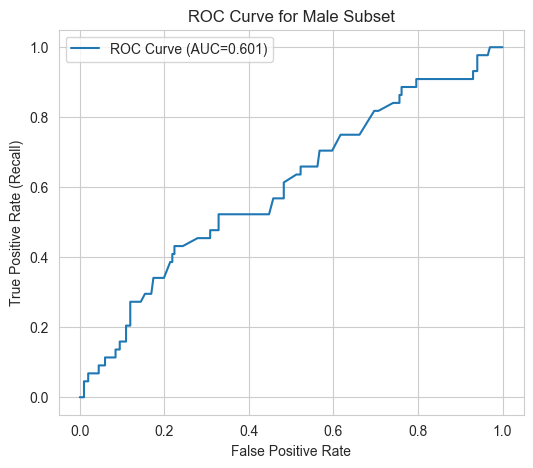

In [1097]:
fpr, tpr, thresholds = roc_curve(y_test, p)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc_score(y_test, p):.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Male Subset')
plt.legend()
plt.show()